In [1]:
import pandas as pd
import numpy as np
import spikeinterface.extractors as se
import spikeinterface.preprocessing as sp
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import numpy as np
import neurokit2 as nk
import tdt

c:\Users\sjs93\anaconda3\envs\resp_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
datapath = r"D:\spikegadgets\20250407_114703sx3_20.rec\20250407_114703sx3_20.rec"
#se.read is the class function used to read in spikegadgets it requres file path and stream id = trodes for ephys ECU is used for medpc
recording = se.read_spikegadgets(datapath, stream_id = 'ECU')
print(recording)

SpikeGadgetsRecordingExtractor: 12 channels - 20.0kHz - 1 segments - 2,130,081 samples 
                                106.50s (1.78 minutes) - int16 dtype - 48.75 MiB
  file_path: D:\spikegadgets\20250407_114703sx3_20.rec\20250407_114703sx3_20.rec


Available channels: ['ECU_Ain1' 'ECU_Ain2' 'ECU_Ain3' 'ECU_Ain4' 'ECU_Ain5' 'ECU_Ain6'
 'ECU_Ain7' 'ECU_Ain8' 'ECU_Aout1' 'ECU_Aout2' 'ECU_Aout3' 'ECU_Aout4']


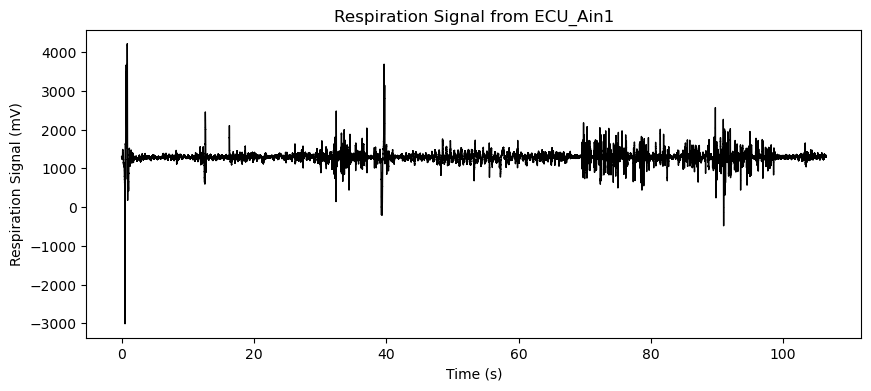

In [6]:

# Define file path
datapath = r"D:\spikegadgets\20250407_114703sx3_20.rec\20250407_114703sx3_20.rec"

# Load recording
recording = se.read_spikegadgets(datapath, stream_id='ECU')

# Print available channel IDs
channel_ids = recording.get_channel_ids()
print("Available channels:", channel_ids)
# Define respiration channel (ECU_Ain1)
resp_channel = 'ECU_Ain1'

# Get sampling rate
fs = recording.get_sampling_frequency()  # Should be around 1-2kHz for ECU

# Extract respiration signal
resp_signal = recording.get_traces(channel_ids=[resp_channel]).flatten()

# Create time array
time = np.arange(len(resp_signal)) / fs  # Convert samples to time (seconds)

# Plot respiration signal
plt.figure(figsize=(10, 4))
plt.plot(time, resp_signal, color='black', linewidth=1)
plt.xlabel("Time (s)")
plt.ylabel("Respiration Signal (mV)")
plt.title(f"Respiration Signal from {resp_channel}")
plt.grid(False)
plt.show()

In [9]:
elec_noise_freq=60
# https://pmc.ncbi.nlm.nih.gov/articles/PMC3130311/ paper suggested these min and max cut offs
min_freq=30
max_freq=1000
resample_rate=1000

In [10]:
datapath = r"D:\spikegadgets\20250407_114703sx3_20.rec\20250407_114703sx3_20.rec"
#se.read is the class function used to read in spikegadgets it requres file path and stream id = trodes for ephys ECU is used for medpc
recording = se.read_spikegadgets(datapath, stream_id = 'ECU')
print(recording)
# removes the noise from the reccording notch filter removes a given freq. 
recording = sp.notch_filter(recording, freq=elec_noise_freq)
# sets filter for a min and max cutoff
recording = sp.bandpass_filter(recording, freq_min=min_freq, freq_max=max_freq)
# resamples transforms data into sampling rates HZ
recording = sp.resample(recording, resample_rate=resample_rate)

SpikeGadgetsRecordingExtractor: 12 channels - 20.0kHz - 1 segments - 2,130,081 samples 
                                106.50s (1.78 minutes) - int16 dtype - 48.75 MiB
  file_path: D:\spikegadgets\20250407_114703sx3_20.rec\20250407_114703sx3_20.rec
